# EDA Stage 4 Report

This notebook is the streamlined EDA notebook for the current branch. It focuses on the active strategy-relevant analysis for `PART1`, `PART2`, `PART3`, and `PART123`.


In [1]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
DATASETS = ["PART1", "PART2", "PART3", "PART123"]
print(f"Project root: {ROOT}")
print(f"Datasets: {', '.join(DATASETS)}")

Project root: C:\Users\ALIENWARE\Desktop\COMP396\COMP396-Group-Project
Datasets: PART1, PART2, PART3, PART123


## Method Settings

These are rolling analysis windows, not fixed calendar slices. The notebook uses the full requested dataset and applies these windows consistently across parts.


In [2]:
from EDA.settings import *

print("Active EDA method settings")
print(f"Trading days per year: {TRADING_DAYS_PER_YEAR}")
print(f"ACF/PACF lags: {ACF_LAGS}")
print(f"Hurst rolling window: {HURST_WINDOW}")
print(f"Volatility windows: {VOL_SHORT_WINDOW}, {VOL_LONG_WINDOW}")
print(f"ATR window: {ATR_WINDOW}")
print(f"Quantiles: {N_QUANTILES}")
print(f"Quantile tests: {QUANTILE_TESTS}")

Active EDA method settings
Trading days per year: 252
ACF/PACF lags: 40
ACF/PACF y-axis range: (-0.3, 0.3)
Hurst rolling window: 252
Volatility windows: 20, 60
ATR window: 14
Quantiles: 5
Quantile tests: STR_21D: lookback=21, forward=21, MOM_126D: lookback=126, forward=21


## Dataset Overview

This section summarizes the four data partitions and the combined `PART123` dataset used for the Stage 4 EDA overview.


In [3]:
dataset_summary = pd.read_csv(ROOT / "EDA/output/stage_4_part123_overview/stage_4_dataset_summary.csv")
dataset_summary

Dataset overview

Dataset  Assets     Rows Date range                 Mean return   Mean vol
---------------------------------------------------------------------------
PART1        10   10,000 2069-12-08 to 2072-09-02        -4.29%     16.49%
PART2        10   10,000 2072-09-03 to 2075-05-30        27.85%     19.48%
PART3        10   10,000 2075-05-31 to 2078-02-23        25.96%     22.65%
PART123      10   30,000 2069-12-08 to 2078-02-23        51.88%     19.77%


## Overview Charts

These are the tracked overview charts generated by `EDA/scripts/build_part123_overview.py`.


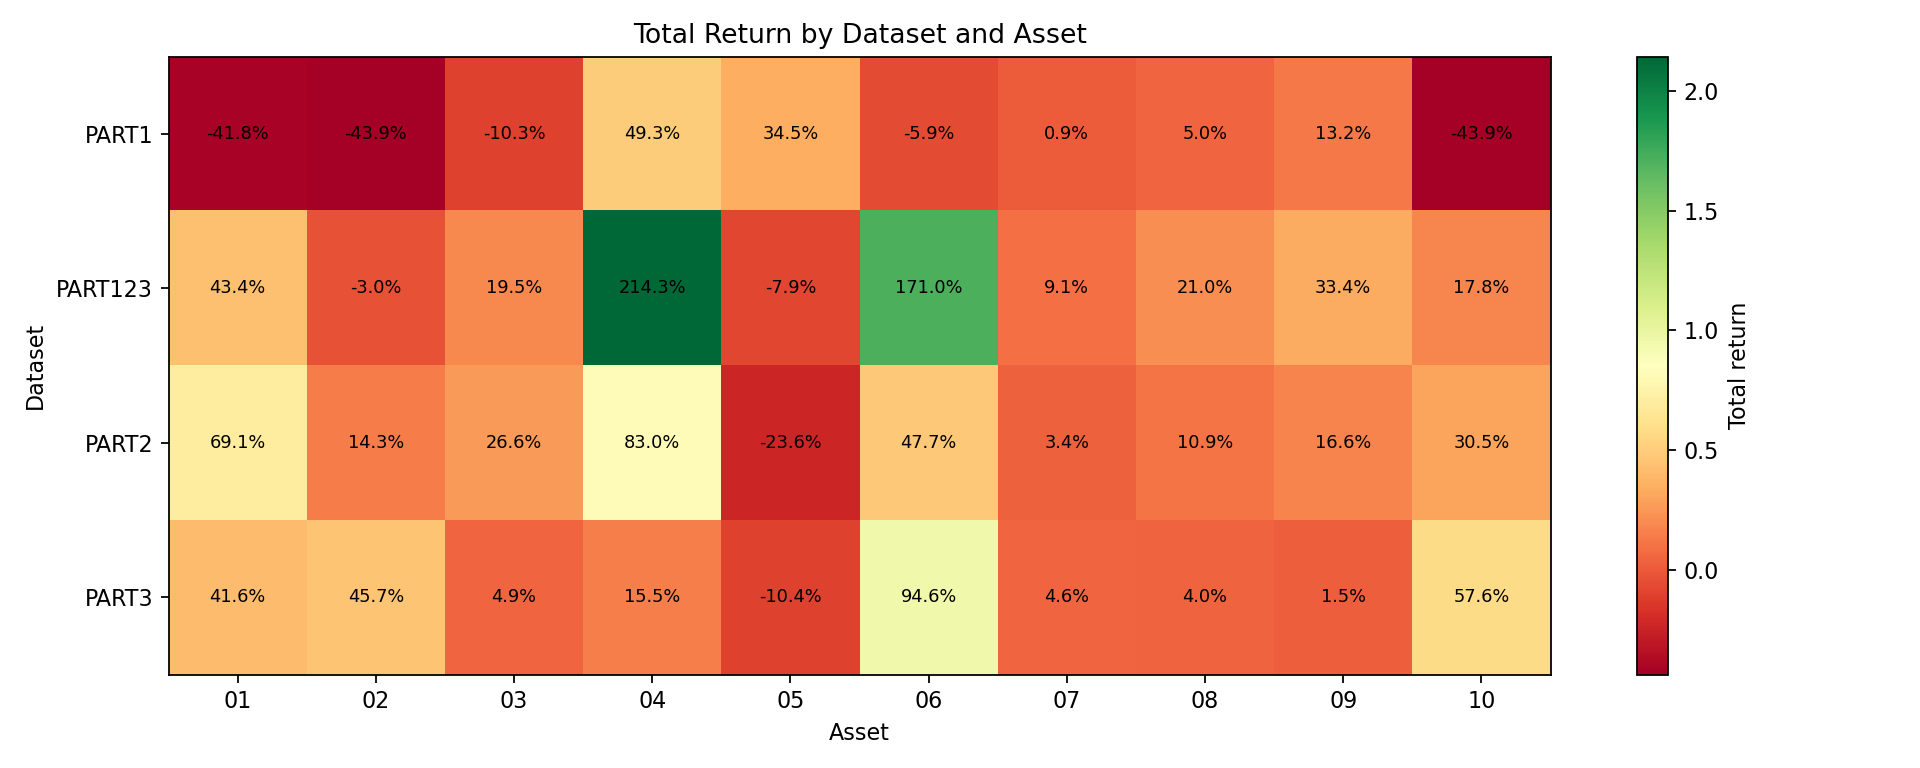

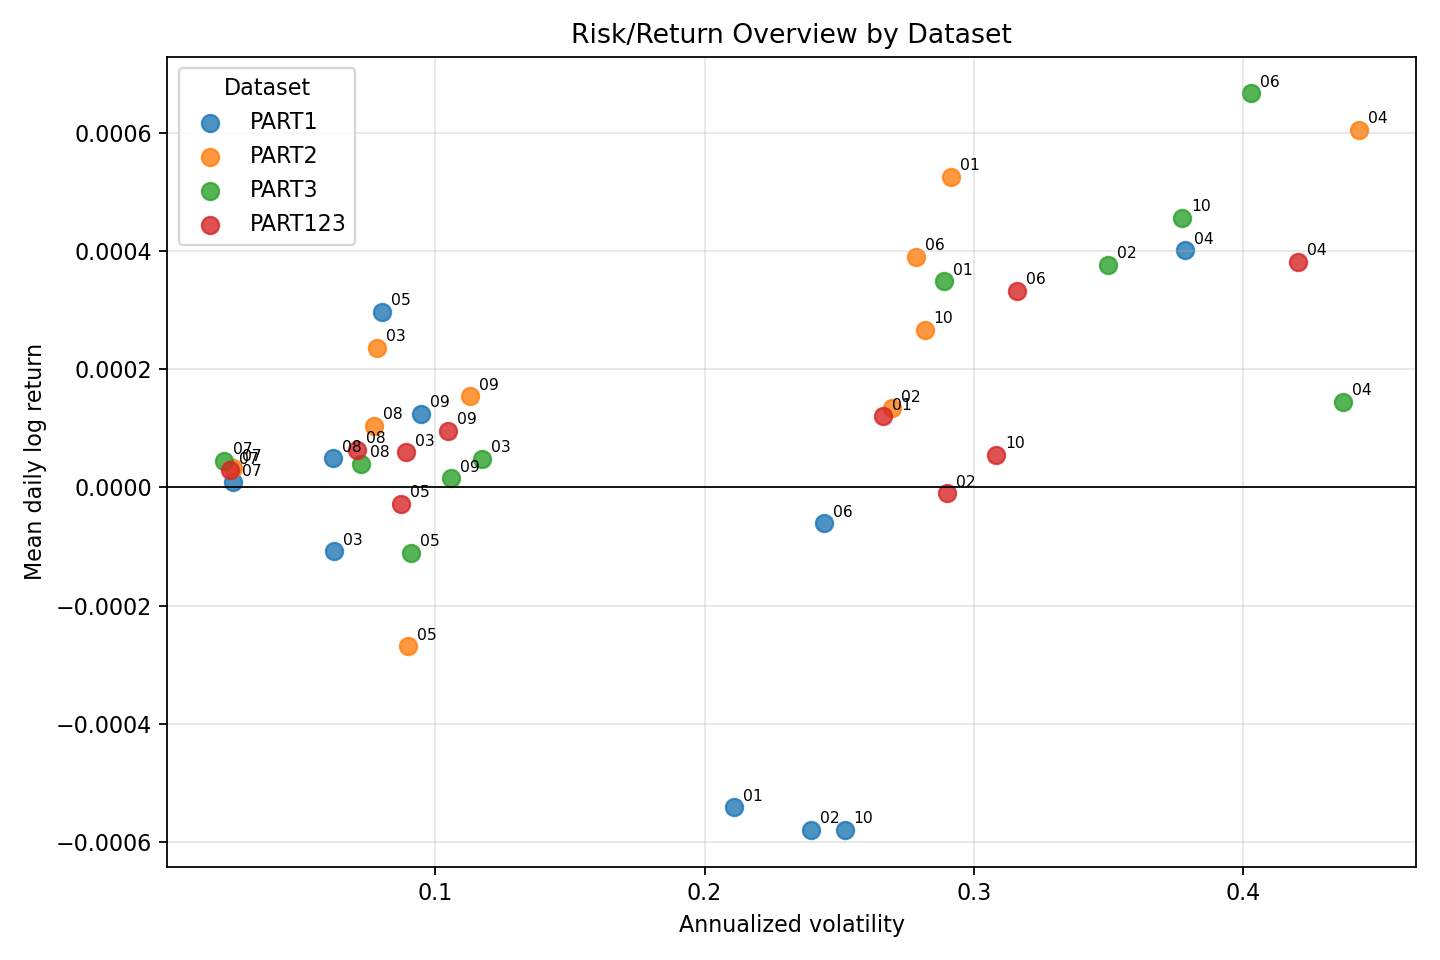

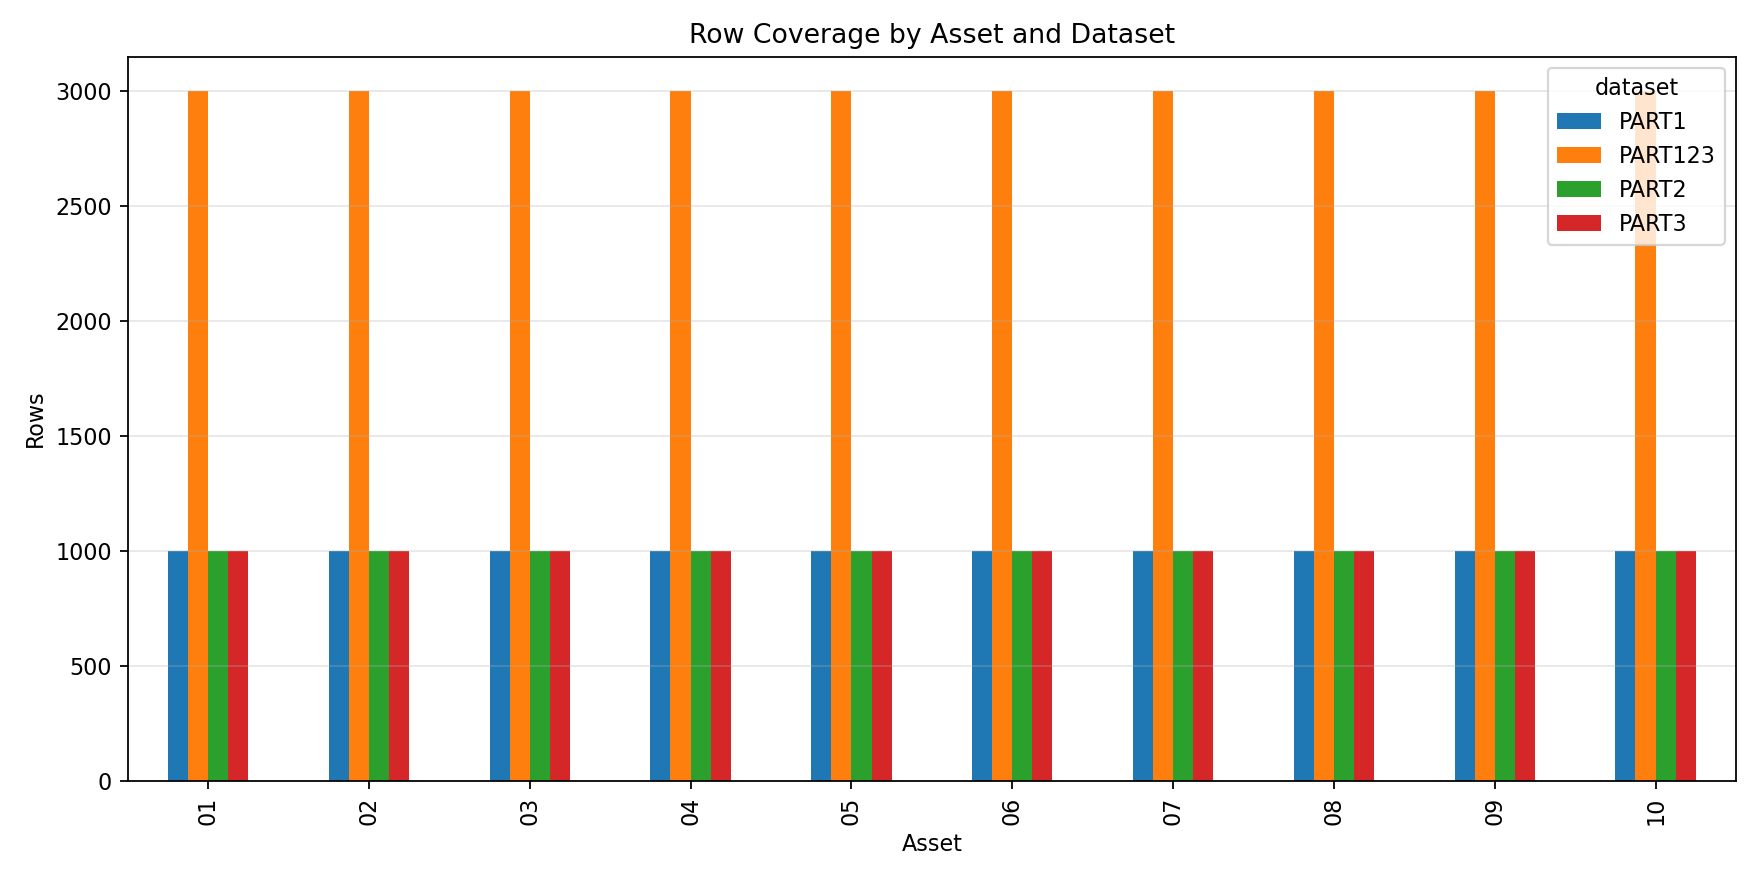

In [4]:
from IPython.display import Image, display

for chart in [
    ROOT / "EDA/output/stage_4_part123_overview/stage_4_total_return_heatmap.png",
    ROOT / "EDA/output/stage_4_part123_overview/stage_4_risk_return_overview.png",
    ROOT / "EDA/output/stage_4_part123_overview/stage_4_row_coverage.png",
]:
    display(Image(filename=str(chart)))

## PART123 Analysis Extract

The following values are extracted from `EDA/docs/stage_4_part123_overview/stage_4_latest_analysis.md`, which is generated from the EDA run logs.


In [5]:
analysis_text = (ROOT / "EDA/docs/stage_4_part123_overview/stage_4_latest_analysis.md").read_text(encoding="utf-8")
start = analysis_text.index("## PART123")
end = analysis_text.find("\n## PART", start + 1)
print(analysis_text[start:end if end != -1 else None])

## PART123

Chart families: `acf`, `correlation_heatmap`, `garch`, `histograms`, `hurst`, `price_overview`, `quantile_analysis`, `volatility`

### Correlation

- Mean pairwise correlation: `0.0760`
- Max positive correlation: `0.7029`
- Min negative correlation: `-0.4030`

### ADF / Autocorrelation

- Stationary log-return series at 5% level: `10/10`

| Asset | ADF p-value |
| --- | ---: |
| 01 | 0.000000 |
| 02 | 0.000000 |
| 03 | 0.000000 |
| 04 | 0.000000 |
| 05 | 0.000000 |
| 06 | 0.000000 |
| 07 | 0.000000 |
| 08 | 0.000000 |
| 09 | 0.000000 |
| 10 | 0.000000 |

### GARCH Volatility Persistence

- Assets with alpha + beta > 0.95: `10/10`

| Asset | Alpha + Beta |
| --- | ---: |
| 01 | 0.9875 |
| 02 | 0.9943 |
| 03 | 0.9951 |
| 04 | 0.9827 |
| 05 | 0.9973 |
| 06 | 0.9980 |
| 07 | 0.9750 |
| 08 | 0.9965 |
| 09 | 0.9970 |
| 10 | 0.9972 |

### Quantile Signal Tests

| Factor | Q1 forward return | Q5 forward return | T-stat | P-value |
| --- | ---: | ---: | ---: | ---: |
| STR_21D | 0.

## Asset-Level Snapshot

This quick readout highlights where the combined `PART123` data is strongest, weakest, and most volatile.


In [6]:
asset_summary = pd.read_csv(ROOT / "EDA/output/stage_4_part123_overview/stage_4_asset_summary.csv")
part123 = asset_summary[asset_summary["dataset"] == "PART123"]
print(part123.sort_values("total_return", ascending=False).head(3)[["asset", "total_return", "annualized_volatility"]])
print(part123.sort_values("total_return", ascending=True).head(3)[["asset", "total_return", "annualized_volatility"]])
print(part123.sort_values("annualized_volatility", ascending=False).head(3)[["asset", "total_return", "annualized_volatility"]])

PART123 asset snapshot

Top total return assets:
- Asset 4: 214.33%, vol 42.04%
- Asset 6: 171.03%, vol 31.60%
- Asset 1: 43.45%, vol 26.64%

Weakest total return assets:
- Asset 5: -7.86%, vol 8.73%
- Asset 2: -2.99%, vol 29.02%
- Asset 7: 9.11%, vol 2.38%

Highest volatility assets:
- Asset 4: vol 42.04%, return 214.33%
- Asset 6: vol 31.60%, return 171.03%
- Asset 10: vol 30.84%, return 17.82%


## Reproducibility

Run the full EDA workflow with:

```powershell
.\EDA\run_all_eda.bat ALL
```

Run the tracked overview only with:

```powershell
.\EDA\run_all_eda.bat OVERVIEW
```

The full analysis text is saved to `EDA/docs/stage_4_part123_overview/stage_4_latest_analysis.md`; run status is saved to `EDA/docs/stage_4_part123_overview/stage_4_latest_run.md`.
